# Diabetes Report EDA: Cross-Category Correlations

This notebook studies how different categories of blood tests move with diabetes-related markers.

Main questions:

1. How are glycemic markers related to renal, lipid, liver, thyroid, vitamin, inflammation, and CBC markers?
2. Which individual parameter pairs have the strongest Pearson and Spearman correlations?
3. Which broad test categories appear most connected to each other?

Notes:

- Pearson correlation captures linear relationships.
- Spearman correlation captures monotonic/rank relationships and is more robust when values are not perfectly linear.
- Correlation does not prove causation.
- Reference ranges are not parsed here; this notebook uses numeric test values only.


In [1]:
from itertools import combinations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from config import CBC, GLYCEMIC, INFLAMMATION, LIPID, LIVER, RENAL, THYROID, VITAMINS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)

DATASET_PATH = ROOT / "data/processed/diabetes_dataset.csv"
LONG_DATASET_PATH = ROOT / "data/processed/diabetes_tests_long.csv"
PLOTS_DIR = ROOT / "plots"
PROCESSED_DIR = ROOT / "data/processed"

PLOTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MIN_PAIR_N = 20
TOP_N = 25


## 1. Load Dataset

The wide dataset has one row per report. Each selected test has columns like `hba1c_value`, `hba1c_unit`, `hba1c_reference`, and `hba1c_abnormal`.


In [2]:
df = pd.read_csv(DATASET_PATH)
tests_long = pd.read_csv(LONG_DATASET_PATH)

df["report_date"] = pd.to_datetime(df["report_date"], errors="coerce")

print("Wide dataset shape:", df.shape)
print("Long dataset shape:", tests_long.shape)
df.head()

Wide dataset shape: (158, 425)
Long dataset shape: (6334, 15)


,research_report_id,research_patient_id,age,gender,report_date,esr_value,esr_unit,esr_reference,esr_abnormal,esr_category,esr_method,esr_technology,tsh_receptor_antibodies_value,tsh_receptor_antibodies_unit,tsh_receptor_antibodies_reference,tsh_receptor_antibodies_abnormal,tsh_receptor_antibodies_category,tsh_receptor_antibodies_method,tsh_receptor_antibodies_technology,crp_value,crp_unit,crp_reference,crp_abnormal,crp_category,crp_method,crp_technology,mch_value,mch_unit,mch_reference,mch_abnormal,mch_category,mch_method,mch_technology,mcv_value,mcv_unit,mcv_reference,mcv_abnormal,mcv_category,mcv_method,mcv_technology,...,urea_reference,urea_abnormal,urea_category,urea_method,urea_technology,calcium_value,calcium_unit,calcium_reference,calcium_abnormal,calcium_category,calcium_method,calcium_technology,t3_value,t3_unit,t3_reference,t3_abnormal,t3_category,t3_method,t3_technology,t4_value,t4_unit,t4_reference,t4_abnormal,t4_category,t4_method,t4_technology,egfr_value,egfr_unit,egfr_reference,egfr_abnormal,egfr_category,egfr_method,egfr_technology,mchc_value,mchc_unit,mchc_reference,mchc_abnormal,mchc_category,mchc_method,mchc_technology
0,REP_7FDD89308DB3,PAT_B9B2F428348A,38.0,Male,2026-02-05,21.0,mm / hr,<50 yr : Male: 0-15 mm/hr Female: 0-20 mm/hr |...,False,General,MODIFIED WESTERGREN,MODIFIED WESTERGREN,1.73,I U/L,Normal : <=2.58 IU/L,False,THYROID,ONE-STEP IMMUNOENZYMATIC (SANDWICH) ASSAY.,C.M.I.A,3.72,mg/L,Acute phase determination : <5 mg/L,False,LIVER,FULLY AUTOMATED LATEX AGGLUTINATION – BECKMAN ...,IMMUNOTURBIDIMETRY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,REP_F673D0B97B46,PAT_B48CCC5F7765,42.0,Female,2026-05-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.6,pq,27.0-32.0,True,COMPLETE HEMOGRAM,NaN,NaN,81.1,fL,83.0-101.0,True,COMPLETE HEMOGRAM,NaN,NaN,...,Adult : 17-43,False,RENAL,NaN,CALCULATED,9.00,mg/dL,8.8-10.6,False,RENAL,NaN,PHOTOMETRY,90.0,n g/dL,80-200,False,THYROID,NaN,E.C.L.I.A,6.68,μ g/dL,4.8-12.7,False,THYROID,NaN,E.C.L.I.A,121.0,mL/min/1.73 m2,> = 90 : Normal | 60 - 89 : Mild Decrease | 45...,False,General,2021 CKD EPI Creatinine Equation,CALCULATED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,REP_A7DE9961F1F1,PAT_B48CCC5F7765,42.0,Female,2026-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.1,pq,27.0-32.0,False,COMPLETE HEMOGRAM,NaN,Calculated,93.2,fL,83.0-101.0,False,COMPLETE HEMOGRAM,NaN,Calculated,...,Adult : 17-43,False,RENAL,NaN,CALCULATED,9.07,mg/dL,8.8-10.6,False,RENAL,NaN,PHOTOMETRY,87.0,n g/dL,80-200,False,THYROID,NaN,E.C.L.I.A,6.26,μ g/dL,4.8-12.7,False,THYROID,NaN,E.C.L.I.A,113.0,mL/min/1.73 m2,> = 90 : Normal | 60 - 89 : Mild Decrease | 45...,False,General,2021 CKD EPI Creatinine Equation,CALCULATED,30.1,g/dL,31.5-34.5,True,COMPLETE HEMOGRAM,NaN,NaN
3,REP_A9496F35A9F5,PAT_D8DF89849A42,56.0,Male,2025-11-17,5.0,mm / hr,Male: 0-15 Female : 0-20,False,General,MODIFIED WESTERGREN,MODIFIED WESTERGREN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.95,mg/L,Acute phase determination : <5 mg/L,False,LIVER,FULLY AUTOMATED LATEX AGGLUTINATION – BECKMAN ...,IMMUNOTURBIDIMETRY,27.2,pq,27.0-32.0,False,COMPLETE HEMOGRAM,NaN,Calculated,84.5,fL,83.0-101.0,False,COMPLETE HEMOGRAM,NaN,Calculated,...,Adult : 17-43,False,RENAL,NaN,CALCULATED,9.64,mg/dL,8.8-10.6,False,RENAL,NaN,PHOTOMETRY,140.0,n g/dL,80-200,False,THYROID,NaN,E.C.L.I.A,8.95,μ g/dL,4.8-12.7,False,THYROID,NaN,E.C.L.I.A,83.0,mL/min/1.73 m2,>=90,True,RENAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,REP_8B481BE5CEDC,PAT_7079A832612F,28.0,Male,2025-11-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,pq,27.0-32.0,False,COMPLETE HEMOGRAM,NaN,Calculated,92.0,fL,83.0-101.0,False,COMPLETE HEMOGRAM,NaN,Calculated,...,Adult : 17-43,False,RENAL,NaN,CALCULATED,10.11,mg/dL,8.8-10.6,False,RENAL,

In [3]:
df[["research_report_id", "research_patient_id", "age", "gender", "report_date"]].describe(include="all")

,research_report_id,research_patient_id,age,gender,report_date
count,158,158,122.000000,158,122
unique,158,136,NaN,2,NaN
top,REP_7FDD89308DB3,PAT_7079A832612F,NaN,Male,NaN
freq,1,4,NaN,89,NaN
mean,NaN,NaN,47.245902,NaN,2026-02-06 22:25:34.426229504
min,NaN,NaN,6.000000,NaN,2025-09-15 00:00:00
25%,NaN,NaN,38.250000,NaN,2025-12-04 00:00:00
50%,NaN,NaN,49.000000,NaN,2026-01-26 12:00:00
75%,NaN,NaN,56.750000,NaN,2026-04-23 00:00:00
max,NaN,NaN,82.000000,NaN,2026-07-28 00:00:00


## 2. Define Test Categories

The categories come directly from `config.py`. This keeps the EDA tied to the same parameters used during dataset creation.


In [4]:
CATEGORY_MAPS = {
    "glycemic": GLYCEMIC,
    "renal": RENAL,
    "lipid": LIPID,
    "liver": LIVER,
    "thyroid": THYROID,
    "vitamins": VITAMINS,
    "inflammation": INFLAMMATION,
    "cbc": CBC,
}


def value_columns_for(mapping):
    columns = []
    seen = set()
    for column in mapping.values():
        value_column = f"{column}_value"
        if value_column in df.columns and value_column not in seen:
            columns.append(value_column)
            seen.add(value_column)
    return columns


CATEGORY_COLUMNS = {
    category: value_columns_for(mapping)
    for category, mapping in CATEGORY_MAPS.items()
}

category_overview = []
for category, columns in CATEGORY_COLUMNS.items():
    for column in columns:
        category_overview.append({
            "category": category,
            "parameter": column.replace("_value", ""),
            "column": column,
            "non_null_reports": int(df[column].notna().sum()),
            "missing_reports": int(df[column].isna().sum()),
        })

category_overview = pd.DataFrame(category_overview)
category_overview.sort_values(["category", "non_null_reports"], ascending=[True, False])

,category,parameter,column,non_null_reports,missing_reports
49,cbc,hemoglobin,hemoglobin_value,122,36
50,cbc,wbc,wbc_value,122,36
51,cbc,platelet_count,platelet_count_value,122,36
54,cbc,mcv,mcv_value,122,36
55,cbc,mch,mch_value,122,36
57,cbc,rdw_cv,rdw_cv_value,122,36
58,cbc,rdw_sd,rdw_sd_value,122,36
59,cbc,mpv,mpv_value,104,54
52,cbc,hematocrit,hematocrit_value,88,70
53,cbc,rbc,rbc_value,88,70


In [5]:
category_counts = (
    category_overview
    .groupby("category")
    .agg(
        parameters=("parameter", "count"),
        median_non_null_reports=("non_null_reports", "median"),
        min_non_null_reports=("non_null_reports", "min"),
        max_non_null_reports=("non_null_reports", "max"),
    )
    .sort_values("parameters", ascending=False)
)
category_counts

,parameters,median_non_null_reports,min_non_null_reports,max_non_null_reports
category,,,,
lipid,14,118.0,103,119
liver,12,118.0,118,125
cbc,11,122.0,79,122
renal,11,116.0,52,119
thyroid,4,118.5,2,122
glycemic,3,124.0,56,124
inflammation,3,9.0,8,108
vitamins,2,98.0,94,102


## 3. Missingness by Category

Before trusting correlations, check how many reports have values for each parameter. Correlations from very small sample sizes are unstable, so the notebook uses `MIN_PAIR_N` to filter weak sample sizes.


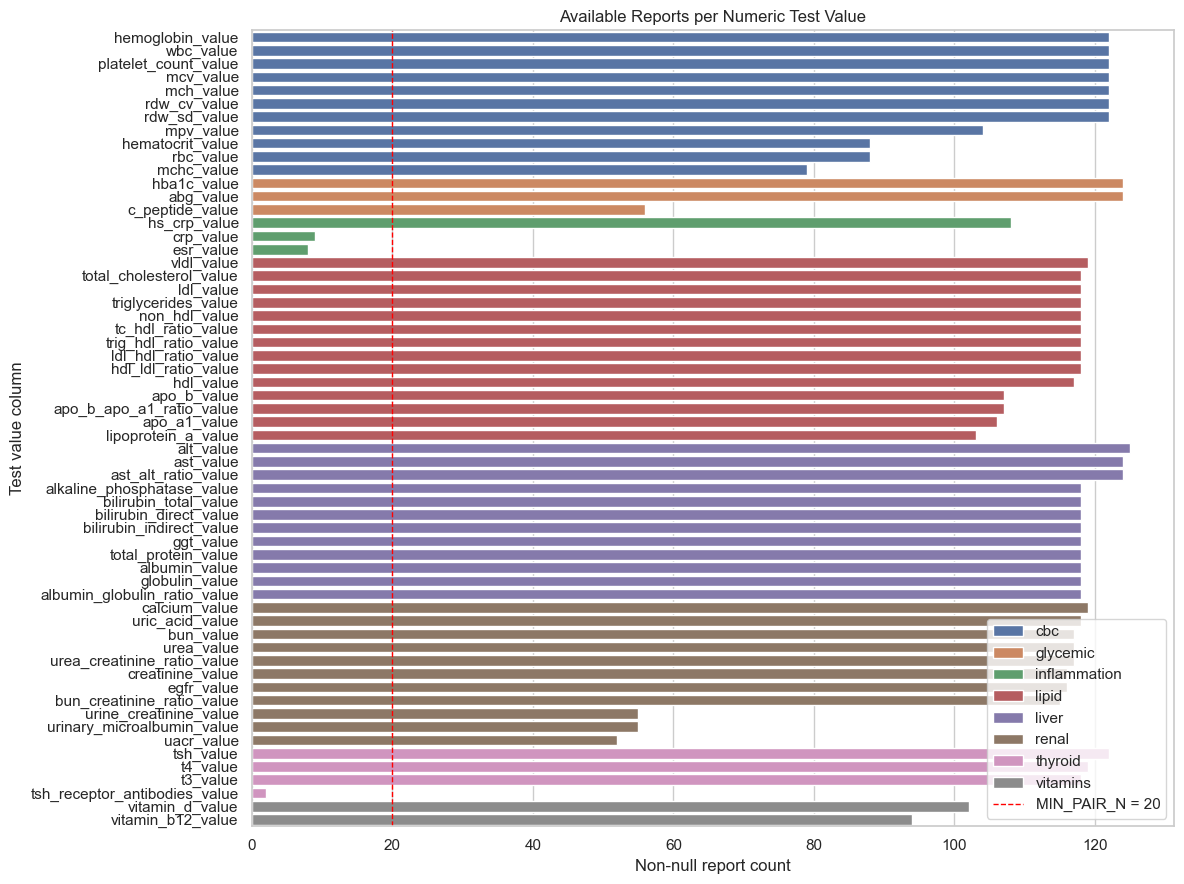

In [6]:
plt.figure(figsize=(12, 9))
plot_data = category_overview.sort_values(["category", "non_null_reports"], ascending=[True, False])
sns.barplot(data=plot_data, y="column", x="non_null_reports", hue="category", dodge=False)
plt.axvline(MIN_PAIR_N, color="red", linestyle="--", linewidth=1, label=f"MIN_PAIR_N = {MIN_PAIR_N}")
plt.title("Available Reports per Numeric Test Value")
plt.xlabel("Non-null report count")
plt.ylabel("Test value column")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Helper Functions for Correlation

For every category pair, we compute all parameter-to-parameter correlations.

Example: `glycemic` vs `renal` includes `hba1c_value` vs `creatinine_value`, `hba1c_value` vs `egfr_value`, `abg_value` vs `urea_value`, etc.


In [7]:
def clean_parameter_name(value_column):
    return value_column.replace("_value", "")


def correlation_between_columns(data, column_a, column_b, method):
    pair = data[[column_a, column_b]].dropna()
    n = len(pair)

    if n < MIN_PAIR_N:
        return np.nan, n

    if pair[column_a].nunique() < 2 or pair[column_b].nunique() < 2:
        return np.nan, n

    return pair[column_a].corr(pair[column_b], method=method), n


def parameter_correlations_for_pair(category_a, category_b, method):
    rows = []
    columns_a = CATEGORY_COLUMNS[category_a]
    columns_b = CATEGORY_COLUMNS[category_b]

    for column_a in columns_a:
        for column_b in columns_b:
            if column_a == column_b:
                continue

            corr, n = correlation_between_columns(df, column_a, column_b, method)
            rows.append({
                "method": method,
                "category_a": category_a,
                "parameter_a": clean_parameter_name(column_a),
                "category_b": category_b,
                "parameter_b": clean_parameter_name(column_b),
                "n": n,
                "correlation": corr,
                "abs_correlation": abs(corr) if pd.notna(corr) else np.nan,
            })

    return rows


def all_parameter_correlations(method):
    rows = []
    for category_a, category_b in combinations(CATEGORY_COLUMNS.keys(), 2):
        rows.extend(parameter_correlations_for_pair(category_a, category_b, method))
    return pd.DataFrame(rows)


## 5. Pearson and Spearman Across Every Category Combination

This table compares every category pair and summarizes all parameter-level correlations inside that pair.


In [8]:
pearson_pairs = all_parameter_correlations("pearson")
spearman_pairs = all_parameter_correlations("spearman")
all_pairs = pd.concat([pearson_pairs, spearman_pairs], ignore_index=True)

valid_pairs = all_pairs.dropna(subset=["correlation"]).copy()
valid_pairs.to_csv(PROCESSED_DIR / "eda_parameter_correlations.csv", index=False)

print("Total tested parameter pairs:", len(all_pairs))
print("Valid parameter pairs after MIN_PAIR_N filter:", len(valid_pairs))
valid_pairs.head()

Total tested parameter pairs: 2980
Valid parameter pairs after MIN_PAIR_N filter: 2644


,method,category_a,parameter_a,category_b,parameter_b,n,correlation,abs_correlation
0,pearson,glycemic,hba1c,renal,creatinine,116,-0.099456,0.099456
1,pearson,glycemic,hba1c,renal,egfr,116,0.101437,0.101437
2,pearson,glycemic,hba1c,renal,bun,117,0.137792,0.137792
3,pearson,glycemic,hba1c,renal,urea,117,0.137776,0.137776
4,pearson,glycemic,hba1c,renal,uric_acid,117,-0.061738,0.061738


In [9]:
category_pair_summary = (
    valid_pairs
    .groupby(["method", "category_a", "category_b"])
    .agg(
        parameter_pairs=("correlation", "count"),
        mean_correlation=("correlation", "mean"),
        mean_abs_correlation=("abs_correlation", "mean"),
        max_abs_correlation=("abs_correlation", "max"),
        median_n=("n", "median"),
        min_n=("n", "min"),
    )
    .reset_index()
    .sort_values(["method", "mean_abs_correlation"], ascending=[True, False])
)

category_pair_summary.to_csv(PROCESSED_DIR / "eda_category_pair_summary.csv", index=False)
category_pair_summary

,method,category_a,category_b,parameter_pairs,mean_correlation,mean_abs_correlation,max_abs_correlation,median_n,min_n
1,pearson,glycemic,inflammation,3,0.390476,0.390476,0.540204,105.0,50
6,pearson,glycemic,vitamins,6,-0.009389,0.203432,0.319660,93.0,46
2,pearson,glycemic,lipid,42,0.124661,0.197370,0.400804,105.0,49
14,pearson,liver,inflammation,12,-0.066825,0.181675,0.557261,105.0,105
27,pearson,vitamins,inflammation,2,0.031471,0.180428,0.211899,97.0,93
9,pearson,lipid,inflammation,14,0.057055,0.175140,0.503253,107.0,103
3,pearson,glycemic,liver,36,0.021801,0.154028,0.476823,117.0,51
13,pearson,liver,cbc,132,0.057154,0.146798,0.410012,117.0,77
10,pearson,lipid,liver,168,0.018960,0.143622,0.443512,116.0,103
17,pearson,renal,cbc,121,-0.006531,0.143391,0.402071,100.0,31


## 6. Strongest Parameter Correlations Overall

These are the strongest individual relationships across all category combinations. Review `n` before interpreting a correlation.


In [10]:
strongest_pearson = (
    valid_pairs[valid_pairs["method"] == "pearson"]
    .sort_values("abs_correlation", ascending=False)
    .head(TOP_N)
)
strongest_pearson

,method,category_a,parameter_a,category_b,parameter_b,n,correlation,abs_correlation
1458,pearson,inflammation,hs_crp,cbc,wbc,105,0.813150,0.813150
1224,pearson,liver,albumin,inflammation,hs_crp,105,-0.557261,0.557261
135,pearson,glycemic,c_peptide,inflammation,hs_crp,50,0.540204,0.540204
1104,pearson,lipid,apo_b_apo_a1_ratio,cbc,wbc,105,0.524514,0.524514
965,pearson,lipid,apo_b_apo_a1_ratio,inflammation,hs_crp,107,0.503253,0.503253
90,pearson,glycemic,abg,liver,alkaline_phosphatase,117,0.476823,0.476823
78,pearson,glycemic,hba1c,liver,alkaline_phosphatase,117,0.476797,0.476797
691,pearson,lipid,hdl,liver,ast_alt_ratio,115,0.443512,0.443512
150,pearson,glycemic,abg,cbc,wbc,119,0.432269,0.432269
139,pearson,glycemic,hba1c,cbc,wbc,119,0.431974,0.431974


In [11]:
strongest_spearman = (
    valid_pairs[valid_pairs["method"] == "spearman"]
    .sort_values("abs_correlation", ascending=False)
    .head(TOP_N)
)
strongest_spearman

,method,category_a,parameter_a,category_b,parameter_b,n,correlation,abs_correlation
2239,spearman,lipid,tc_hdl_ratio,liver,alt,116,0.569031,0.569031
2263,spearman,lipid,ldl_hdl_ratio,liver,alt,116,0.540404,0.540404
2275,spearman,lipid,hdl_ldl_ratio,liver,alt,116,-0.540122,0.540122
2241,spearman,lipid,tc_hdl_ratio,liver,ast_alt_ratio,116,-0.533070,0.533070
2179,spearman,lipid,hdl,liver,alt,115,-0.527610,0.527610
2246,spearman,lipid,tc_hdl_ratio,liver,ggt,116,0.510361,0.510361
2311,spearman,lipid,apo_b_apo_a1_ratio,liver,alt,105,0.505230,0.505230
2265,spearman,lipid,ldl_hdl_ratio,liver,ast_alt_ratio,116,-0.504463,0.504463
2277,spearman,lipid,hdl_ldl_ratio,liver,ast_alt_ratio,116,0.502714,0.502714
2181,spearman,lipid,hdl,liver,ast_alt_ratio,115,0.473525,0.473525


## 7. Diabetes-Focused Correlations: Glycemic vs Other Categories

This section focuses specifically on diabetes markers (`HbA1c`, `ABG`, `C-peptide`) against every non-glycemic category.


In [12]:
glycemic_vs_others = valid_pairs[
    (valid_pairs["category_a"] == "glycemic") | (valid_pairs["category_b"] == "glycemic")
].copy()

glycemic_vs_others.sort_values(["method", "abs_correlation"], ascending=[True, False]).head(50)

,method,category_a,parameter_a,category_b,parameter_b,n,correlation,abs_correlation
135,pearson,glycemic,c_peptide,inflammation,hs_crp,50,0.540204,0.540204
90,pearson,glycemic,abg,liver,alkaline_phosphatase,117,0.476823,0.476823
78,pearson,glycemic,hba1c,liver,alkaline_phosphatase,117,0.476797,0.476797
150,pearson,glycemic,abg,cbc,wbc,119,0.432269,0.432269
139,pearson,glycemic,hba1c,cbc,wbc,119,0.431974,0.431974
59,pearson,glycemic,abg,lipid,apo_b_apo_a1_ratio,105,0.400804,0.400804
45,pearson,glycemic,hba1c,lipid,apo_b_apo_a1_ratio,105,0.400733,0.400733
26,pearson,glycemic,c_peptide,renal,uric_acid,50,0.393632,0.393632
41,pearson,glycemic,hba1c,lipid,ldl_hdl_ratio,116,0.363126,0.363126
55,pearson,glycemic,abg,lipid,ldl_hdl_ratio,116,0.362994,0.362994


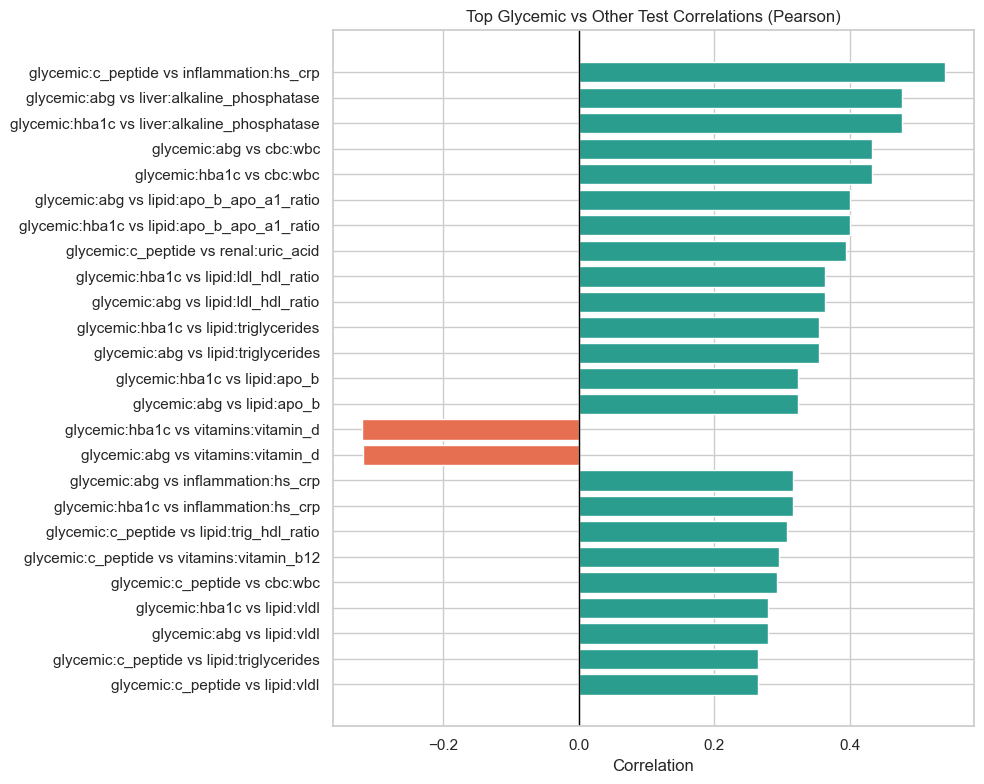

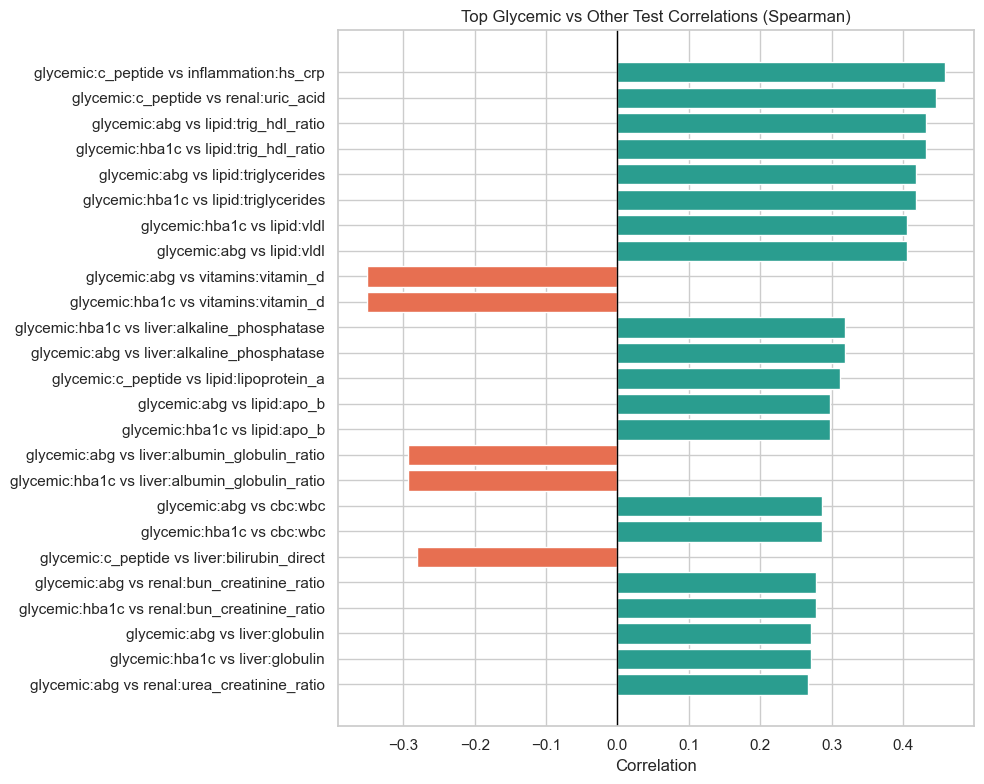

In [13]:
for method in ["pearson", "spearman"]:
    method_data = glycemic_vs_others[glycemic_vs_others["method"] == method]
    top = method_data.sort_values("abs_correlation", ascending=False).head(TOP_N)

    plt.figure(figsize=(10, 8))
    labels = (
        top["category_a"] + ":" + top["parameter_a"]
        + " vs "
        + top["category_b"] + ":" + top["parameter_b"]
    )
    colors = np.where(top["correlation"] >= 0, "#2A9D8F", "#E76F51")
    plt.barh(labels[::-1], top["correlation"][::-1], color=colors[::-1])
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Top Glycemic vs Other Test Correlations ({method.title()})")
    plt.xlabel("Correlation")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## 8. Category-Level Profiles

To summarize broad category relationships, each parameter is standardized as a z-score and then averaged within its category.

Important: this is not a clinical health score. It is only a numeric profile showing whether categories tend to move together across reports.


In [14]:
category_profiles = pd.DataFrame(index=df.index)

for category, columns in CATEGORY_COLUMNS.items():
    available = [column for column in columns if df[column].notna().sum() >= MIN_PAIR_N]
    zscores = pd.DataFrame(index=df.index)

    for column in available:
        std = df[column].std(skipna=True)
        if pd.isna(std) or std == 0:
            continue
        zscores[column] = (df[column] - df[column].mean(skipna=True)) / std

    category_profiles[category] = zscores.mean(axis=1, skipna=True)

category_profiles = category_profiles.dropna(how="all")
category_profiles.head()

,glycemic,renal,lipid,liver,thyroid,vitamins,inflammation,cbc
1,-0.519757,0.546255,-0.873259,-0.521903,-0.332066,-0.140691,-0.261765,-0.770149
2,-0.634911,0.014483,-0.726334,-0.471726,-0.833022,-0.131422,-0.159685,-0.230202
3,-0.769734,0.159894,0.083741,0.237466,0.614229,-0.021954,-0.161204,-0.046454
4,-0.986785,0.076160,-0.205703,0.238940,0.292129,0.357788,-0.166065,0.049704
5,0.194210,-0.418969,0.095170,-0.323972,-1.257277,-0.931237,-0.216801,-0.231397


In [15]:
pearson_category_matrix = category_profiles.corr(method="pearson", min_periods=MIN_PAIR_N)
spearman_category_matrix = category_profiles.corr(method="spearman", min_periods=MIN_PAIR_N)

pearson_category_matrix.to_csv(PROCESSED_DIR / "eda_category_profile_pearson.csv")
spearman_category_matrix.to_csv(PROCESSED_DIR / "eda_category_profile_spearman.csv")

pearson_category_matrix

,glycemic,renal,lipid,liver,thyroid,vitamins,inflammation,cbc
glycemic,1.000000,0.210239,0.299422,0.051475,-0.080445,-0.154808,0.397156,0.182021
renal,0.210239,1.000000,0.121067,0.004539,-0.003331,0.060402,0.148852,0.017761
lipid,0.299422,0.121067,1.000000,0.064426,-0.034756,-0.035032,0.139331,0.155258
liver,0.051475,0.004539,0.064426,1.000000,0.232560,-0.113937,-0.132478,0.352934
thyroid,-0.080445,-0.003331,-0.034756,0.232560,1.000000,-0.113696,-0.221712,0.165042
vitamins,-0.154808,0.060402,-0.035032,-0.113937,-0.113696,1.000000,-0.138552,-0.141900
inflammation,0.397156,0.148852,0.139331,-0.132478,-0.221712,-0.138552,1.000000,0.194042
cbc,0.182021,0.017761,0.155258,0.352934,0.165042,-0.141900,0.194042,1.000000


In [16]:
spearman_category_matrix

,glycemic,renal,lipid,liver,thyroid,vitamins,inflammation,cbc
glycemic,1.000000,0.184294,0.285293,-0.005644,-0.045976,-0.129997,0.260460,0.158255
renal,0.184294,1.000000,0.113669,0.057933,0.010364,0.109805,0.131595,-0.018096
lipid,0.285293,0.113669,1.000000,0.114538,0.013480,-0.040311,0.202480,0.184877
liver,-0.005644,0.057933,0.114538,1.000000,0.217519,-0.173542,0.000574,0.367274
thyroid,-0.045976,0.010364,0.013480,0.217519,1.000000,-0.138624,0.031342,0.161409
vitamins,-0.129997,0.109805,-0.040311,-0.173542,-0.138624,1.000000,0.017241,-0.169431
inflammation,0.260460,0.131595,0.202480,0.000574,0.031342,0.017241,1.000000,0.000985
cbc,0.158255,-0.018096,0.184877,0.367274,0.161409,-0.169431,0.000985,1.000000


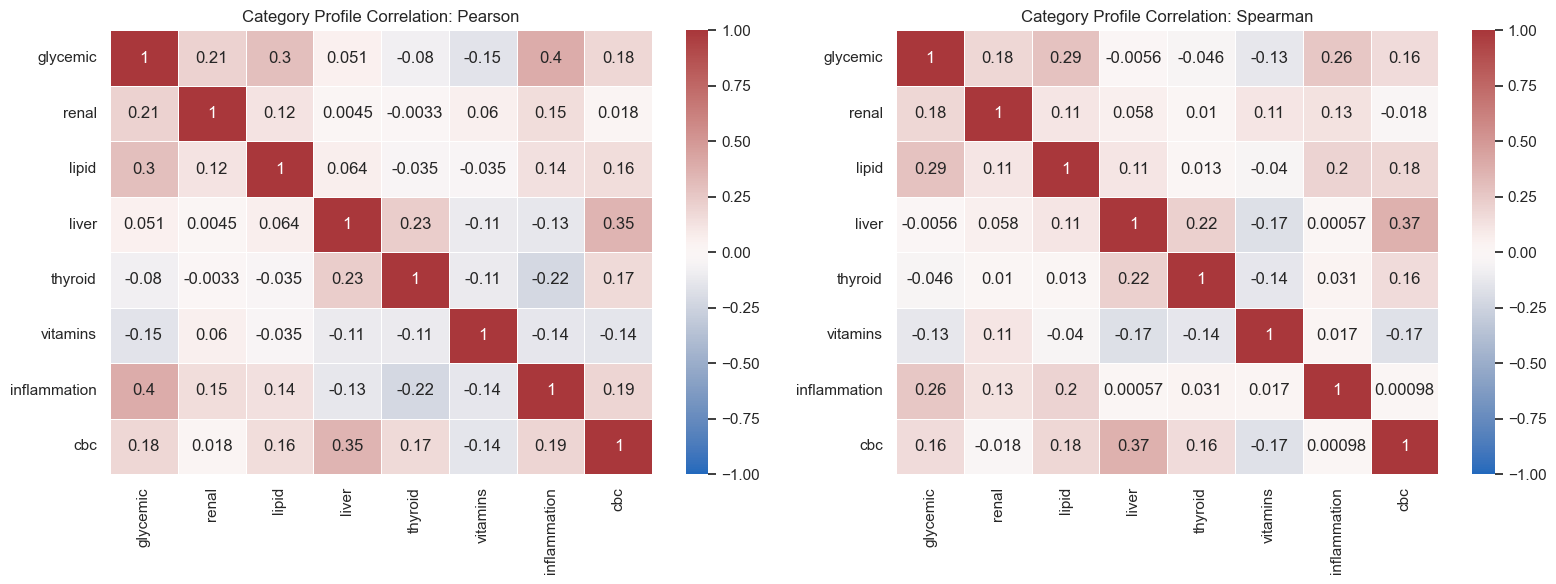

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    pearson_category_matrix,
    annot=True,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("Category Profile Correlation: Pearson")

sns.heatmap(
    spearman_category_matrix,
    annot=True,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("Category Profile Correlation: Spearman")

plt.tight_layout()
plt.show()

## 9. Detailed Heatmaps: Glycemic vs Each Category

These heatmaps show whether glycemic markers are positively or negatively correlated with each category's individual markers.


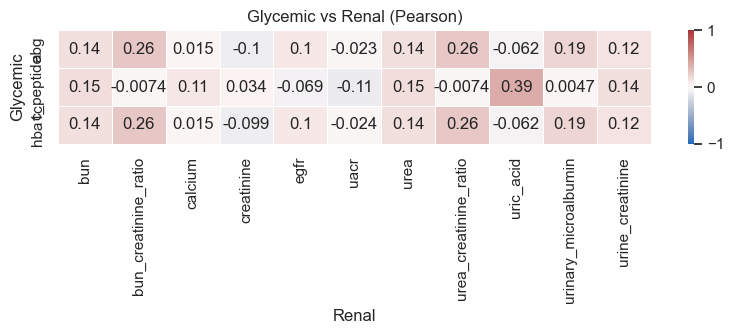

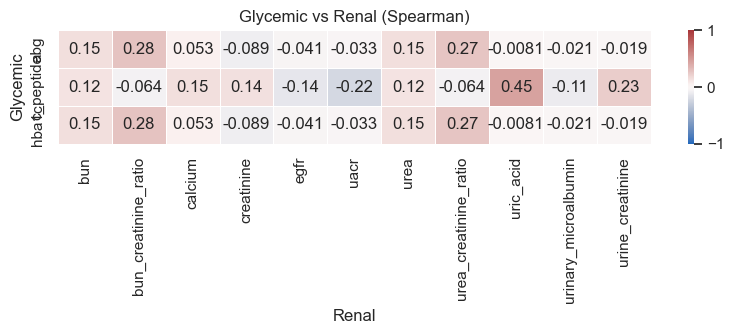

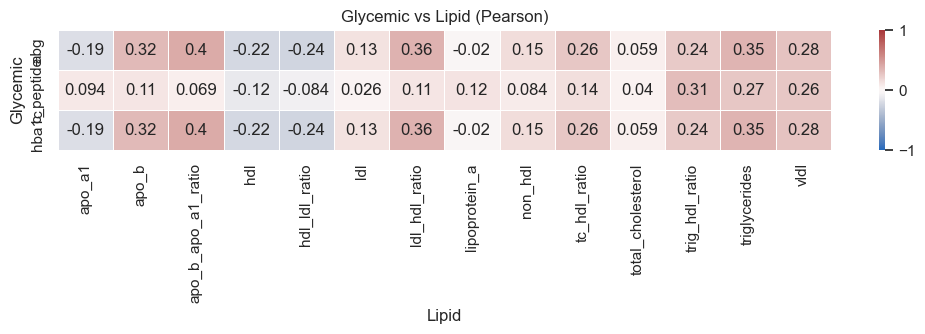

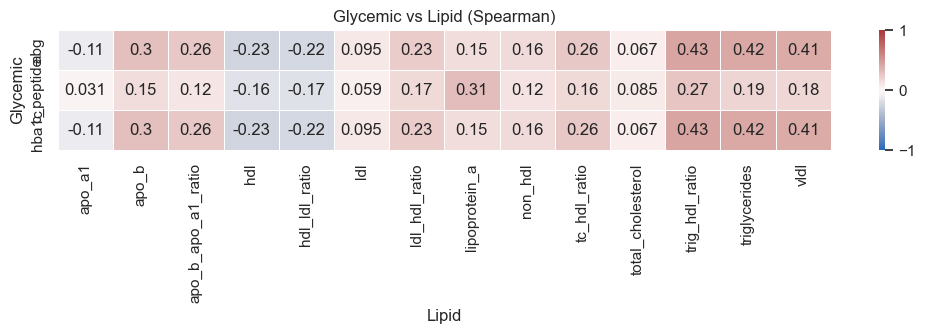

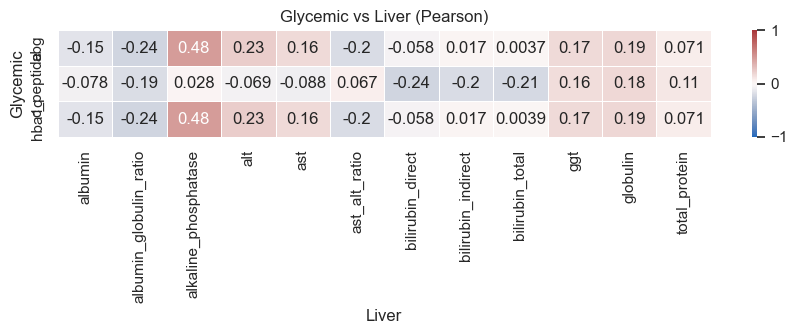

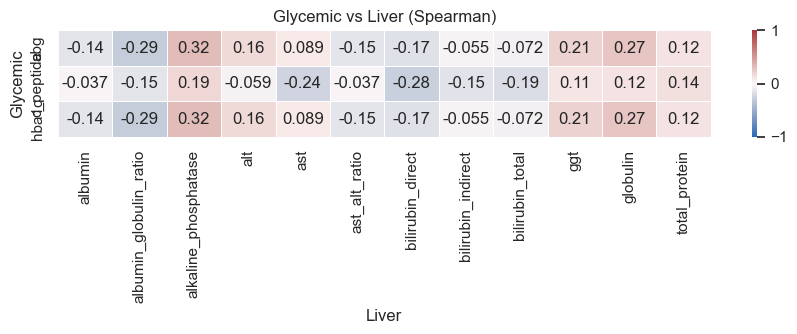

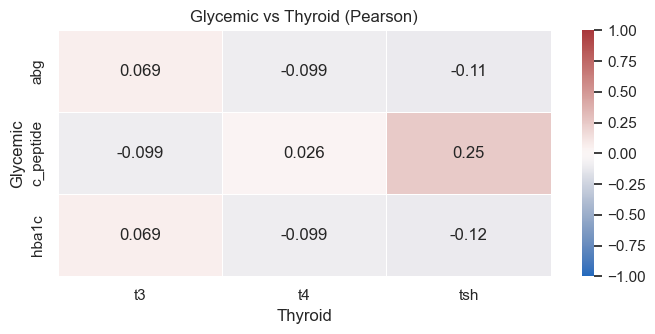

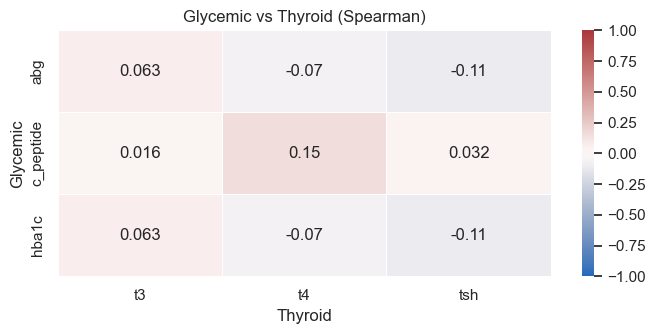

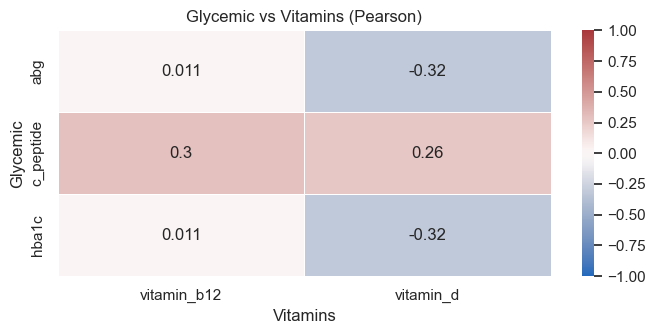

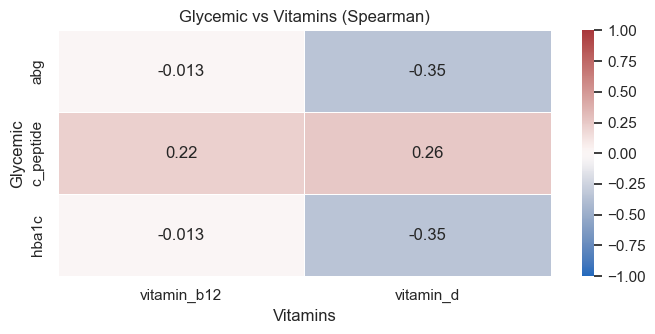

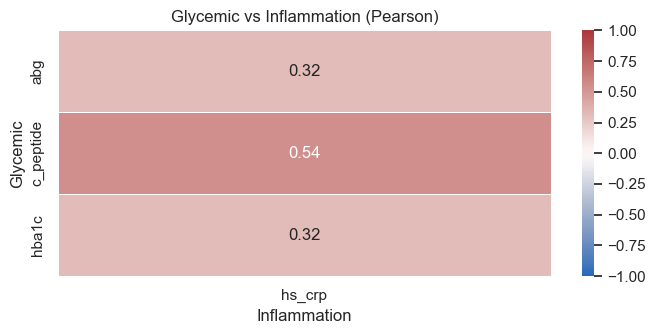

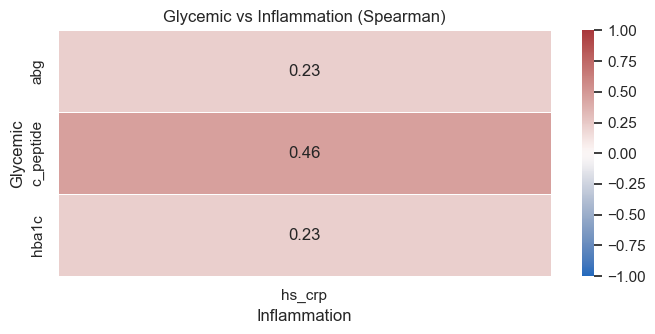

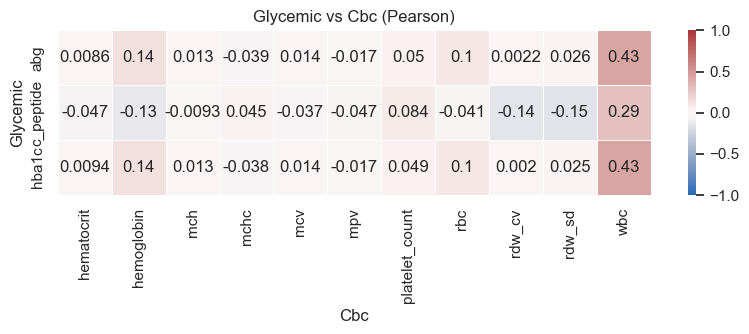

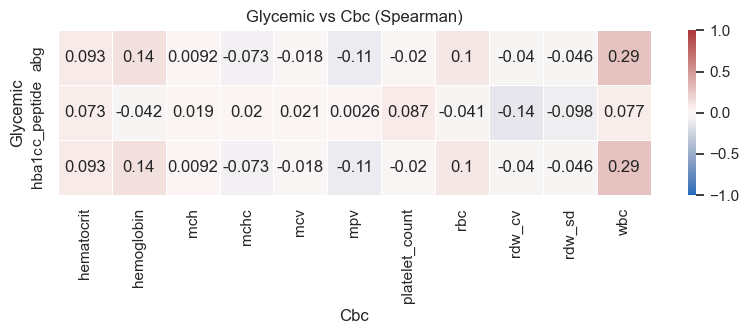

In [18]:
def category_heatmap(category_a, category_b, method):
    rows = parameter_correlations_for_pair(category_a, category_b, method)
    table = pd.DataFrame(rows).dropna(subset=["correlation"])

    if table.empty:
        print(f"No valid correlations for {category_a} vs {category_b} using {method}.")
        return

    matrix = table.pivot(index="parameter_a", columns="parameter_b", values="correlation")

    plt.figure(figsize=(max(7, matrix.shape[1] * 0.75), max(3.5, matrix.shape[0] * 0.75)))
    sns.heatmap(matrix, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1, linewidths=0.5)
    plt.title(f"{category_a.title()} vs {category_b.title()} ({method.title()})")
    plt.xlabel(category_b.title())
    plt.ylabel(category_a.title())
    plt.tight_layout()
    plt.show()


for category in [c for c in CATEGORY_COLUMNS if c != "glycemic"]:
    category_heatmap("glycemic", category, "pearson")
    category_heatmap("glycemic", category, "spearman")

## 10. Interpretation Template

Use this section to write conclusions after reviewing the tables and heatmaps.

Suggested interpretation structure:

1. Start with glycemic vs renal because kidney function is clinically important in diabetes.
2. Compare Pearson and Spearman. If Spearman is stronger, the relationship may be monotonic but not linear.
3. Check sample size `n` before trusting a result.
4. Look for consistency across related parameters, not just one strong pair.
5. Treat this as hypothesis generation, not proof.


In [19]:
print("Files created by this notebook:")
print(PROCESSED_DIR / "eda_parameter_correlations.csv")
print(PROCESSED_DIR / "eda_category_pair_summary.csv")
print(PROCESSED_DIR / "eda_category_profile_pearson.csv")
print(PROCESSED_DIR / "eda_category_profile_spearman.csv")

Files created by this notebook:
/Users/rehnooraulakh/Documents/Diabetes DataScience/data/processed/eda_parameter_correlations.csv
/Users/rehnooraulakh/Documents/Diabetes DataScience/data/processed/eda_category_pair_summary.csv
/Users/rehnooraulakh/Documents/Diabetes DataScience/data/processed/eda_category_profile_pearson.csv
/Users/rehnooraulakh/Documents/Diabetes DataScience/data/processed/eda_category_profile_spearman.csv
